# Results

In [22]:
from py_experimenter.experimenter import PyExperimenter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Load Data

In [23]:
TABLE_NAMES_NORMALIZED = [
    "new_stopping_successive_halving_no_es",
    "new_stopping_successive_halving_es",
    "new_stopping_hyperband_no_es",
    "new_stopping_hyperband_es",
    "new_stopping_priorband_no_es",
    "new_stopping_priorband_es",
]
TABLE_NAMES_SH_UNNORMALIZED = [
    "new_stopping_successive_halving_no_es",
    "new_stopping_successive_halving_es",
]
TABLE_NAMES_SYNTHETIC = [
    "new_stopping_synthetic_no_es",
    "new_stopping_synthetic_es",
]
update_data = True

def get_data(table_name: str, update_data: bool) -> pd.DataFrame | None:
    cache_path = f"plain_data/{table_name}/table.csv"
    if update_data:
        try:
            experimenter = PyExperimenter(
                experiment_configuration_file_path="conf/experiment_config.yml",
                database_credential_file_path="conf/database_credentials.yml",
                table_name=table_name,
            )
            df = experimenter.get_table()
            os.makedirs(os.path.dirname(cache_path), exist_ok=True)
            df.to_csv(cache_path, index=False)
            return df
        except Exception as e:
            print(f"Could not load '{table_name}' from DB: {e}")
            if os.path.exists(cache_path):
                print(f"  Falling back to cached data for '{table_name}'.")
                return pd.read_csv(cache_path)
            return None
    else:
        if not os.path.exists(cache_path):
            print(f"No cache found for '{table_name}', skipping.")
            return None
        return pd.read_csv(cache_path)

dfs_norm = [get_data(t, update_data) for t in TABLE_NAMES_NORMALIZED]
available_norm = [d for d in dfs_norm if d is not None and not d.empty]
if not available_norm:
    raise RuntimeError("No normalized experiment data found.")
df = pd.concat(available_norm, ignore_index=True)
df = df[df["status"] == "done"]
df_lcbench = df[df["benchmark"] == "lcbench"]
print(f"{len(df_lcbench)} completed normalized lcbench experiments")

dfs_unnorm = [get_data(t, update_data) for t in TABLE_NAMES_SH_UNNORMALIZED]
available_unnorm = [d for d in dfs_unnorm if d is not None and not d.empty]
if available_unnorm:
    df_unnorm = pd.concat(available_unnorm, ignore_index=True)
    df_unnorm = df_unnorm[df_unnorm["status"] == "done"]
    df_lcbench_unnorm = df_unnorm[df_unnorm["benchmark"] == "lcbench"]
    print(f"{len(df_lcbench_unnorm)} completed unnormalized SH lcbench experiments")
else:
    df_lcbench_unnorm = pd.DataFrame()
    print("No unnormalized SH data available.")

dfs_synthetic = [get_data(t, update_data) for t in TABLE_NAMES_SYNTHETIC]
available_synthetic = [d for d in dfs_synthetic if d is not None and not d.empty]
if available_synthetic:
    df_synthetic = pd.concat(available_synthetic, ignore_index=True)
    df_synthetic = df_synthetic[df_synthetic["status"] == "done"]
    print(f"{len(df_synthetic)} completed synthetic experiments")
else:
    df_synthetic = pd.DataFrame()
    print("No synthetic data available.")

df_lcbench.head()

2026-05-06 23:23:34,027  | py-experimenter - INFO     | Found 14 keyfields
2026-05-06 23:23:34,028  | py-experimenter - INFO     | Found 6 resultfields
2026-05-06 23:23:34,028  | py-experimenter - INFO     | Found 2 logtables
2026-05-06 23:23:34,029  | py-experimenter - INFO     | Found logtable test_priorband__sh_iterations
2026-05-06 23:23:34,029  | py-experimenter - INFO     | Found logtable test_priorband__brackets
2026-05-06 23:23:34,029  | py-experimenter - WARNING  | No custom section defined in config
2026-05-06 23:23:34,029  | py-experimenter - WARNING  | No codecarbon section defined in config
2026-05-06 23:23:34,035  | py-experimenter - INFO     | Initialized and connected to database


2026-05-06 23:23:34,069  | py-experimenter - INFO     | Found 14 keyfields
2026-05-06 23:23:34,070  | py-experimenter - INFO     | Found 6 resultfields
2026-05-06 23:23:34,070  | py-experimenter - INFO     | Found 2 logtables
2026-05-06 23:23:34,070  | py-experimenter - INFO     | Found logtable test_priorband__sh_iterations
2026-05-06 23:23:34,071  | py-experimenter - INFO     | Found logtable test_priorband__brackets
2026-05-06 23:23:34,071  | py-experimenter - WARNING  | No custom section defined in config
2026-05-06 23:23:34,071  | py-experimenter - WARNING  | No codecarbon section defined in config
2026-05-06 23:23:34,077  | py-experimenter - INFO     | Initialized and connected to database
2026-05-06 23:23:35,526  | py-experimenter - INFO     | Found 14 keyfields
2026-05-06 23:23:35,527  | py-experimenter - INFO     | Found 6 resultfields
2026-05-06 23:23:35,528  | py-experimenter - INFO     | Found 2 logtables
2026-05-06 23:23:35,528  | py-experimenter - INFO     | Found logtabl

59840 completed normalized lcbench experiments


2026-05-06 23:23:37,339  | py-experimenter - INFO     | Found 14 keyfields
2026-05-06 23:23:37,340  | py-experimenter - INFO     | Found 6 resultfields
2026-05-06 23:23:37,340  | py-experimenter - INFO     | Found 2 logtables
2026-05-06 23:23:37,340  | py-experimenter - INFO     | Found logtable test_priorband__sh_iterations
2026-05-06 23:23:37,341  | py-experimenter - INFO     | Found logtable test_priorband__brackets
2026-05-06 23:23:37,341  | py-experimenter - WARNING  | No custom section defined in config
2026-05-06 23:23:37,341  | py-experimenter - WARNING  | No codecarbon section defined in config
2026-05-06 23:23:37,346  | py-experimenter - INFO     | Initialized and connected to database
2026-05-06 23:23:37,364  | py-experimenter - INFO     | Found 14 keyfields
2026-05-06 23:23:37,365  | py-experimenter - INFO     | Found 6 resultfields
2026-05-06 23:23:37,365  | py-experimenter - INFO     | Found 2 logtables
2026-05-06 23:23:37,365  | py-experimenter - INFO     | Found logtabl

51680 completed unnormalized SH lcbench experiments
1600 completed synthetic experiments


,ID,run_id,optimizer,num_arms,benchmark,kernel,use_predicted_y,use_early_stopping,seed,dataset_id,...,name,machine,T_max,consumed_budget,remaining_arms,num_epsilon_optimal_arms,regret,epsilon_optimal,end_date,error
0,1,__AUTO__,successive_halving,256,lcbench,linear,0,0,0,0,...,PyExperimenter,cn0636,52,1152.0,1,16,0.000752,1,2026-05-04 17:55:22,None
1,2,__AUTO__,successive_halving,256,lcbench,linear,0,0,1,0,...,PyExperimenter,cn0123,52,1152.0,1,25,0.000600,1,2026-05-04 17:55:31,None
2,3,__AUTO__,successive_halving,256,lcbench,linear,0,0,2,0,...,PyExperimenter,cn0127,52,1152.0,1,20,0.000825,1,2026-05-04 17:55:33,None
3,4,__AUTO__,successive_halving,256,lcbench,linear,0,0,3,0,...,PyExperimenter,cn0635,52,1152.0,1,20,0.000756,1,2026-05-04 17:55:28,None
4,5,__AUTO__,successive_halving,256,lcbench,linear,0,0,4,0,...,PyExperimenter,cn0737,52,1152.0,1,21,0.000334,1,2026-05-04 17:55:28,None


## Prepare Data

In [24]:
PRIOR_RENAME = {
    "uniform": "Uniform",
    "performance": "Performance",
    "rank": "Rank",
    "inverse_rank": "Inverse Rank",
    "indicator": "Indicator",
}

BASELINE_LABEL = "Baseline"

_tab10 = sns.color_palette("tab10", n_colors=6)
PRIOR_COLOR_MAP = {
    "Rank": _tab10[0],
    "Performance": _tab10[1],
    "Indicator": _tab10[2],
    "Inverse Rank": _tab10[3],
    "Uniform": _tab10[4],
    BASELINE_LABEL: _tab10[5],
}

PRIOR_MARKER_MAP = {
    "Rank": "o",
    "Performance": "s",
    "Indicator": "D",
    "Inverse Rank": "^",
    "Uniform": "v",
    BASELINE_LABEL: "P",
}

def prepare_data(df: pd.DataFrame, optimizer: str, kernel: str = "linear") -> pd.DataFrame | None:
    """Method variants (use_early_stopping=1) + baseline (uniform, no early stopping)."""
    method = df[
        (df["optimizer"] == optimizer)
        & (df["use_early_stopping"] == 1)
        & (df["kernel"] == kernel)
    ].copy()
    baseline = df[
        (df["optimizer"] == optimizer)
        & (df["prior_kind"] == "uniform")
        & (df["use_early_stopping"] == 0)
        & (df["kernel"] == kernel)
    ].copy()
    if method.empty and baseline.empty:
        print(f"No data for optimizer '{optimizer}' with kernel='{kernel}', skipping.")
        return None
    baseline["prior_kind"] = BASELINE_LABEL
    combined = pd.concat([method, baseline], ignore_index=True)
    combined["prior_kind"] = combined["prior_kind"].map(PRIOR_RENAME).fillna(combined["prior_kind"])
    return combined


## Plot

In [25]:
sns.set_theme(style="whitegrid", context="talk")

LABEL_SIZE = 13
TICK_SIZE = 11

MARKER_SIZE = 9
LEGEND_MARKER_SIZE = 10
MARKER_EDGE_WIDTH = 2
CAP_SIZE = 3
ALPHA_BASELINE = 0.6
ALPHA_NORMAL = 0.9

FIG_SIZE_PARETO = (7,4)
FIG_SIZE_ABLATION = (14, 6)
FIG_SIZE_LEGEND = (10, 0.7)

YLIM_REGRET = (0, 0.1)

In [26]:
def pareto_plot(data: pd.DataFrame, xlim=None, ylim=None) -> plt.Figure:
    ranked_priors = (
        data.groupby("prior_kind")["consumed_budget"]
        .mean()
        .sort_values()
        .index.tolist()
    )
    if BASELINE_LABEL in ranked_priors:
        ranked_priors = [p for p in ranked_priors if p != BASELINE_LABEL] + [BASELINE_LABEL]

    fig, ax = plt.subplots(figsize=FIG_SIZE_PARETO)

    for prior in ranked_priors:
        subset = data[data["prior_kind"] == prior]
        m_reg = subset["regret"].mean()
        s_reg = subset["regret"].sem()
        m_bud = subset["consumed_budget"].mean()
        s_bud = subset["consumed_budget"].sem()

        is_baseline = prior == BASELINE_LABEL
        ax.errorbar(
            m_bud, m_reg,
            xerr=s_bud, yerr=s_reg,
            fmt=PRIOR_MARKER_MAP.get(prior, "o"),
            label=prior,
            color=PRIOR_COLOR_MAP.get(prior, "gray"),
            markersize=MARKER_SIZE,
            capsize=CAP_SIZE,
            markeredgewidth=MARKER_EDGE_WIDTH,
            alpha=ALPHA_BASELINE if is_baseline else ALPHA_NORMAL,
            linestyle="--" if is_baseline else "-",
        )

    ax.set_xlabel("Consumed Budget")
    ax.set_ylabel("Regret")
    ax.set_ylim(bottom=0)
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    plt.tight_layout()
    return fig

In [27]:
def sigma_ablation_plot(df: pd.DataFrame, optimizer: str, kernel: str = "linear") -> plt.Figure | None:
    data = df[
        (df["optimizer"] == optimizer)
        & (df["use_early_stopping"] == 1)
        & (df["kernel"] == kernel)
    ].copy()
    data["prior_kind"] = data["prior_kind"].map(PRIOR_RENAME).fillna(data["prior_kind"])
    data["sigma0"] = data["sigma0"].astype(str)
    if data.empty:
        print(f"No early-stopping data for optimizer '{optimizer}' with kernel='{kernel}', skipping sigma ablation.")
        return None

    fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE_ABLATION)

    for ax, metric, ylabel in zip(
        axes,
        ["regret", "consumed_budget"],
        ["Regret", "Consumed Budget"],
    ):
        sns.boxplot(
            data=data,
            x="prior_kind",
            y=metric,
            hue="sigma0",
            ax=ax,
            palette="Set2",
        )
        ax.set_ylabel(ylabel, fontsize=LABEL_SIZE)
        ax.set_xlabel(None)
        ax.tick_params(axis="both", labelsize=TICK_SIZE)
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=TICK_SIZE)
        ax.grid(True, linestyle="--", alpha=0.6, axis="y")
        if ax.get_legend():
            ax.get_legend().remove()

    plt.tight_layout()
    return fig

In [28]:
KERNEL_RENAME = {
    "linear": "Linear",
    "rbf": "RBF",
    "matern32": "Matérn-3/2",
    "matern52": "Matérn-5/2",
    "satexp_rbf": "Sat. Exp. RBF",
}

def kernel_ablation_plot(df: pd.DataFrame, optimizer: str, sigma0: float = 1e-4) -> plt.Figure | None:
    data = df[
        (df["optimizer"] == optimizer)
        & (df["use_early_stopping"] == 1)
        & (df["sigma0"] == sigma0)
    ].copy()
    data["prior_kind"] = data["prior_kind"].map(PRIOR_RENAME).fillna(data["prior_kind"])
    data["kernel"] = data["kernel"].map(KERNEL_RENAME).fillna(data["kernel"])
    if data.empty:
        print(f"No data for optimizer '{optimizer}' with sigma0={sigma0}, skipping kernel ablation.")
        return None

    fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE_ABLATION)

    for ax, metric, ylabel in zip(
        axes,
        ["regret", "consumed_budget"],
        ["Regret", "Consumed Budget"],
    ):
        sns.boxplot(
            data=data,
            x="prior_kind",
            y=metric,
            hue="kernel",
            ax=ax,
            palette="Set2",
        )
        ax.set_ylabel(ylabel, fontsize=LABEL_SIZE)
        ax.set_xlabel(None)
        ax.tick_params(axis="both", labelsize=TICK_SIZE)
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=TICK_SIZE)
        ax.grid(True, linestyle="--", alpha=0.6, axis="y")
        if ax.get_legend():
            ax.get_legend().remove()

    plt.tight_layout()
    return fig

In [29]:
OPTIMIZER_MARKER = {
    "Hyperband": "o",
    "PriorBand": "s",
}

def joined_pareto_plot(
    hb_data: pd.DataFrame,
    pb_data: pd.DataFrame,
    xlim=None,
    ylim=None,
) -> plt.Figure:
    combined = pd.concat(
        [hb_data.assign(optimizer_label="Hyperband"), pb_data.assign(optimizer_label="PriorBand")],
        ignore_index=True,
    )

    all_priors = (
        combined.groupby("prior_kind")["consumed_budget"]
        .mean()
        .sort_values()
        .index.tolist()
    )
    if BASELINE_LABEL in all_priors:
        all_priors = [p for p in all_priors if p != BASELINE_LABEL] + [BASELINE_LABEL]

    fig, ax = plt.subplots(figsize=FIG_SIZE_PARETO)

    for opt_label, marker in OPTIMIZER_MARKER.items():
        subset_opt = combined[combined["optimizer_label"] == opt_label]
        for prior in all_priors:
            subset = subset_opt[subset_opt["prior_kind"] == prior]
            if subset.empty:
                continue
            is_baseline = prior == BASELINE_LABEL
            ax.errorbar(
                subset["consumed_budget"].mean(),
                subset["regret"].mean(),
                xerr=subset["consumed_budget"].sem(),
                yerr=subset["regret"].sem(),
                fmt=marker,
                color=PRIOR_COLOR_MAP.get(prior, "gray"),
                markersize=MARKER_SIZE,
                capsize=CAP_SIZE,
                markeredgewidth=MARKER_EDGE_WIDTH,
                alpha=ALPHA_BASELINE if is_baseline else ALPHA_NORMAL,
                linestyle="None",
                label="_nolegend_",
            )

    ax.set_xlabel("Consumed Budget")
    ax.set_ylabel("Regret")
    ax.set_ylim(bottom=0)
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    plt.tight_layout()
    return fig

In [30]:
def epsilon_optimal_plot(data: pd.DataFrame, ylim=None) -> plt.Figure:
    ranked_priors = (
        data.groupby("prior_kind")["consumed_budget"]
        .mean()
        .sort_values()
        .index.tolist()
    )
    if BASELINE_LABEL in ranked_priors:
        ranked_priors = [p for p in ranked_priors if p != BASELINE_LABEL] + [BASELINE_LABEL]

    fig, ax = plt.subplots(figsize=FIG_SIZE_PARETO)
    x = np.arange(len(ranked_priors))

    for i, prior in enumerate(ranked_priors):
        subset = data[data["prior_kind"] == prior]
        mean = subset["epsilon_optimal"].mean()
        se = subset["epsilon_optimal"].sem()
        is_baseline = prior == BASELINE_LABEL
        ax.bar(
            i, mean,
            color=PRIOR_COLOR_MAP.get(prior, "gray"),
            alpha=ALPHA_BASELINE if is_baseline else ALPHA_NORMAL,
            label=prior,
        )
        ax.errorbar(i, mean, yerr=se, fmt="none", color="black", capsize=CAP_SIZE)

    ax.set_xticks(x)
    ax.set_xticklabels(ranked_priors, rotation=45, ha="right", fontsize=TICK_SIZE)
    ax.set_ylabel("P(epsilon-optimal)", fontsize=LABEL_SIZE)
    ax.set_ylim(bottom=0)
    if ylim is not None:
        ax.set_ylim(ylim)

    plt.tight_layout()
    return fig

In [31]:
def budget_vs_epsilon_optimal_plot(data: pd.DataFrame, xlim=None, ylim=None) -> plt.Figure:
    ranked_priors = (
        data.groupby("prior_kind")["consumed_budget"]
        .mean()
        .sort_values()
        .index.tolist()
    )
    if BASELINE_LABEL in ranked_priors:
        ranked_priors = [p for p in ranked_priors if p != BASELINE_LABEL] + [BASELINE_LABEL]

    fig, ax = plt.subplots(figsize=FIG_SIZE_PARETO)

    for prior in ranked_priors:
        subset = data[data["prior_kind"] == prior]
        m_bud = subset["consumed_budget"].mean()
        s_bud = subset["consumed_budget"].sem()
        m_eps = subset["epsilon_optimal"].mean()
        s_eps = subset["epsilon_optimal"].sem()

        is_baseline = prior == BASELINE_LABEL
        ax.errorbar(
            m_bud, m_eps,
            xerr=s_bud, yerr=s_eps,
            fmt=PRIOR_MARKER_MAP.get(prior, "o"),
            label=prior,
            color=PRIOR_COLOR_MAP.get(prior, "gray"),
            markersize=MARKER_SIZE,
            capsize=CAP_SIZE,
            markeredgewidth=MARKER_EDGE_WIDTH,
            alpha=ALPHA_BASELINE if is_baseline else ALPHA_NORMAL,
            linestyle="--" if is_baseline else "-",
        )

    ax.set_xlabel("Consumed Budget")
    ax.set_ylabel("P(epsilon-optimal)")
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    plt.tight_layout()
    return fig

## Synthetic Ablation

In [32]:
if not df_synthetic.empty:
    _sigma_data = df_synthetic[
        (df_synthetic["optimizer"] == "successive_halving")
        & (df_synthetic["use_early_stopping"] == 1)
        & (df_synthetic["kernel"] == "linear")
    ]
    _sigma0_vals = sorted(_sigma_data["sigma0"].astype(str).unique())
    if _sigma0_vals:
        _set2 = sns.color_palette("Set2", n_colors=len(_sigma0_vals))
        _sigma_handles = [
            plt.Line2D([0], [0], marker="s", color="w",
                       markerfacecolor=c, markeredgecolor=c,
                       markersize=LEGEND_MARKER_SIZE, label=v)
            for v, c in zip(_sigma0_vals, _set2)
        ]
        _fig_ls, _ax_ls = plt.subplots(figsize=FIG_SIZE_LEGEND)
        _ax_ls.axis("off")
        _ax_ls.legend(
            handles=_sigma_handles,
            labels=[h.get_label() for h in _sigma_handles],
            loc="center",
            ncol=len(_sigma_handles),
            title="sigma0",
            frameon=True,
            fontsize=LABEL_SIZE,
        )
        plt.tight_layout()
        os.makedirs("plots/synthetic/successive_halving", exist_ok=True)
        _fig_ls.savefig("plots/synthetic/successive_halving/legend_sigma.pdf", bbox_inches="tight")
        _fig_ls.savefig("plots/synthetic/successive_halving/legend_sigma.png", bbox_inches="tight", dpi=300)
        plt.show()

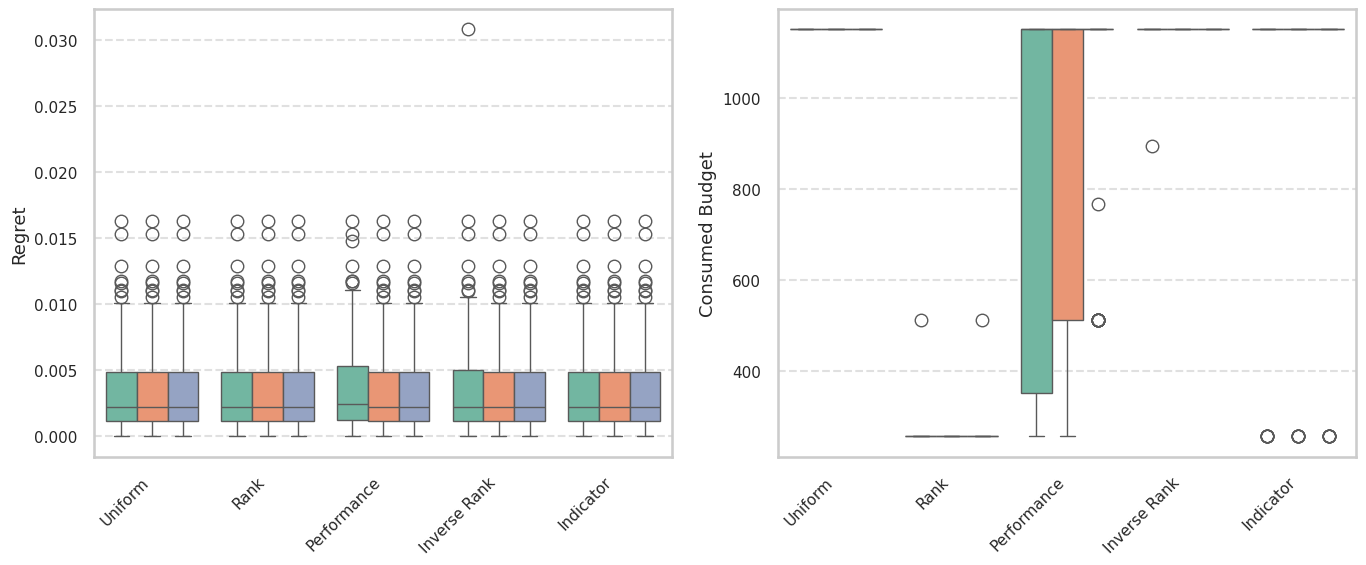

In [33]:
if not df_synthetic.empty:
    fig = sigma_ablation_plot(df_synthetic, "successive_halving", kernel = "satexp_rbf")
    if fig is not None:
        os.makedirs("plots/synthetic/successive_halving", exist_ok=True)
        fig.savefig("plots/synthetic/successive_halving/sigma_ablation.pdf", bbox_inches="tight")
        fig.savefig("plots/synthetic/successive_halving/sigma_ablation.png", bbox_inches="tight", dpi=300)
        plt.show()

## Synthetic

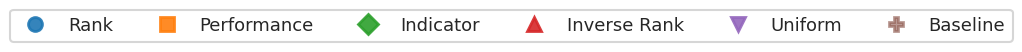

In [34]:
_prior_order = ["Rank", "Performance", "Indicator", "Inverse Rank", "Uniform", BASELINE_LABEL]
_pareto_handles = [
    plt.Line2D(
        [0], [0],
        marker=PRIOR_MARKER_MAP[p],
        color="w",
        markerfacecolor=PRIOR_COLOR_MAP[p],
        markeredgecolor=PRIOR_COLOR_MAP[p],
        markersize=LEGEND_MARKER_SIZE,
        markeredgewidth=MARKER_EDGE_WIDTH,
        alpha=ALPHA_BASELINE if p == BASELINE_LABEL else ALPHA_NORMAL,
        label=p,
    )
    for p in _prior_order
    if p in PRIOR_COLOR_MAP
]
_fig_lp, _ax_lp = plt.subplots(figsize=FIG_SIZE_LEGEND)
_ax_lp.axis("off")
_ax_lp.legend(
    handles=_pareto_handles,
    labels=[h.get_label() for h in _pareto_handles],
    loc="center",
    ncol=len(_pareto_handles),
    frameon=True,
    fontsize=LABEL_SIZE,
)
plt.tight_layout()
os.makedirs("plots/synthetic/successive_halving", exist_ok=True)
_fig_lp.savefig("plots/synthetic/successive_halving/legend_pareto.pdf", bbox_inches="tight")
_fig_lp.savefig("plots/synthetic/successive_halving/legend_pareto.png", bbox_inches="tight", dpi=300)
plt.show()

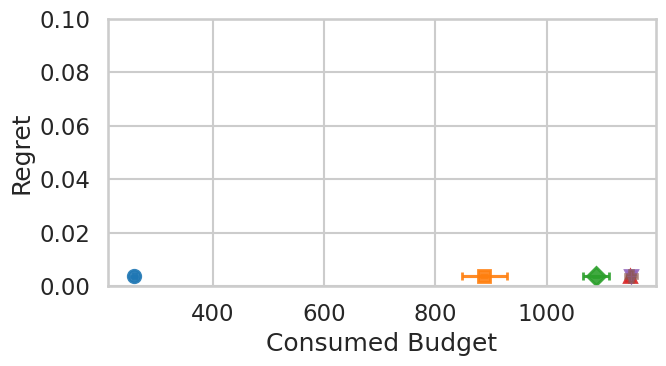

In [35]:
if not df_synthetic.empty:
    sh_synthetic = prepare_data(df_synthetic, "successive_halving", kernel="satexp_rbf")
    if sh_synthetic is not None:
        sh_synthetic = sh_synthetic[(sh_synthetic["sigma0"] == 0.0001) | (sh_synthetic["prior_kind"] == BASELINE_LABEL)]
        fig = pareto_plot(sh_synthetic, ylim=YLIM_REGRET)
        os.makedirs("plots/synthetic/successive_halving", exist_ok=True)
        fig.savefig("plots/synthetic/successive_halving/pareto.pdf", bbox_inches="tight")
        fig.savefig("plots/synthetic/successive_halving/pareto.png", bbox_inches="tight", dpi=300)
        plt.show()

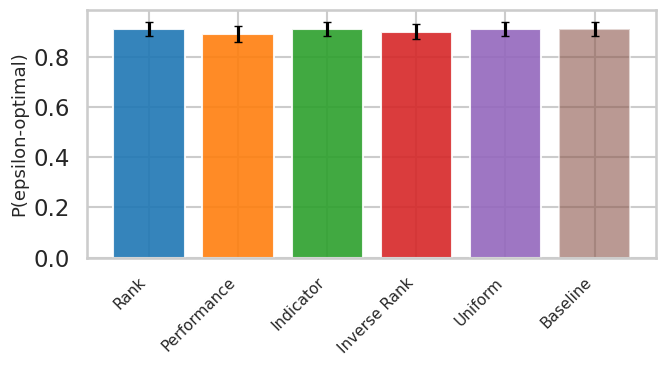

In [36]:
if not df_synthetic.empty and sh_synthetic is not None:
    fig = epsilon_optimal_plot(sh_synthetic)
    os.makedirs("plots/synthetic/successive_halving", exist_ok=True)
    fig.savefig("plots/synthetic/successive_halving/epsilon_optimal.pdf", bbox_inches="tight")
    fig.savefig("plots/synthetic/successive_halving/epsilon_optimal.png", bbox_inches="tight", dpi=300)
    plt.show()

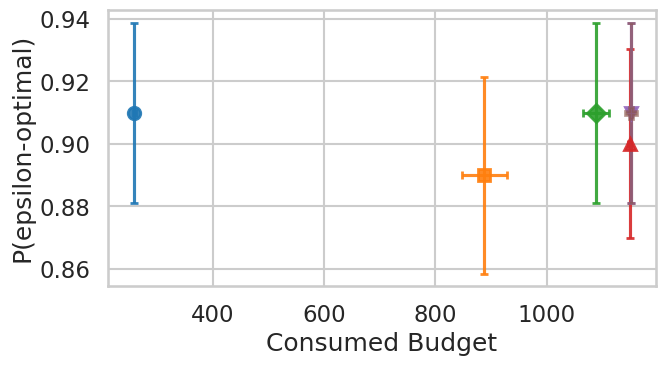

In [37]:
if not df_synthetic.empty and sh_synthetic is not None:
    fig = budget_vs_epsilon_optimal_plot(sh_synthetic)
    os.makedirs("plots/synthetic/successive_halving", exist_ok=True)
    fig.savefig("plots/synthetic/successive_halving/budget_vs_epsilon_optimal.pdf", bbox_inches="tight")
    fig.savefig("plots/synthetic/successive_halving/budget_vs_epsilon_optimal.png", bbox_inches="tight", dpi=300)
    plt.show()

## LCBench

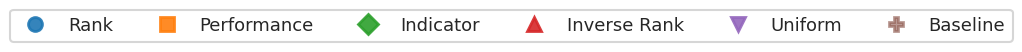

In [38]:
_prior_order = ["Rank", "Performance", "Indicator", "Inverse Rank", "Uniform", BASELINE_LABEL]
_pareto_handles = [
    plt.Line2D(
        [0], [0],
        marker=PRIOR_MARKER_MAP[p],
        color="w",
        markerfacecolor=PRIOR_COLOR_MAP[p],
        markeredgecolor=PRIOR_COLOR_MAP[p],
        markersize=LEGEND_MARKER_SIZE,
        markeredgewidth=MARKER_EDGE_WIDTH,
        alpha=ALPHA_BASELINE if p == BASELINE_LABEL else ALPHA_NORMAL,
        label=p,
    )
    for p in _prior_order
    if p in PRIOR_COLOR_MAP
]
_fig_lp, _ax_lp = plt.subplots(figsize=FIG_SIZE_LEGEND)
_ax_lp.axis("off")
_ax_lp.legend(
    handles=_pareto_handles,
    labels=[h.get_label() for h in _pareto_handles],
    loc="center",
    ncol=len(_pareto_handles),
    frameon=True,
    fontsize=LABEL_SIZE,
)
plt.tight_layout()
os.makedirs("plots/successive_halving", exist_ok=True)
_fig_lp.savefig("plots/successive_halving/legend_pareto.pdf", bbox_inches="tight")
_fig_lp.savefig("plots/successive_halving/legend_pareto.png", bbox_inches="tight", dpi=300)
plt.show()

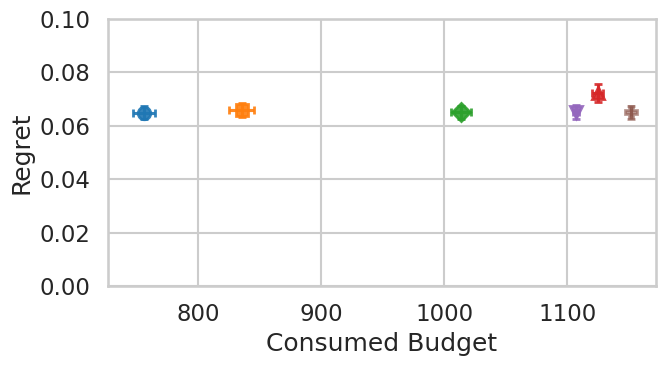

In [39]:
sh_lcbench = prepare_data(df_lcbench, "successive_halving")
if sh_lcbench is not None:
    sh_lcbench = sh_lcbench[(sh_lcbench["sigma0"] == 0.0001) | (sh_lcbench["prior_kind"] == BASELINE_LABEL)]
    fig = pareto_plot(sh_lcbench, ylim=YLIM_REGRET)
    os.makedirs("plots/successive_halving", exist_ok=True)
    fig.savefig("plots/successive_halving/pareto_normalized.pdf", bbox_inches="tight")
    fig.savefig("plots/successive_halving/pareto_normalized.png", bbox_inches="tight", dpi=300)
    plt.show()

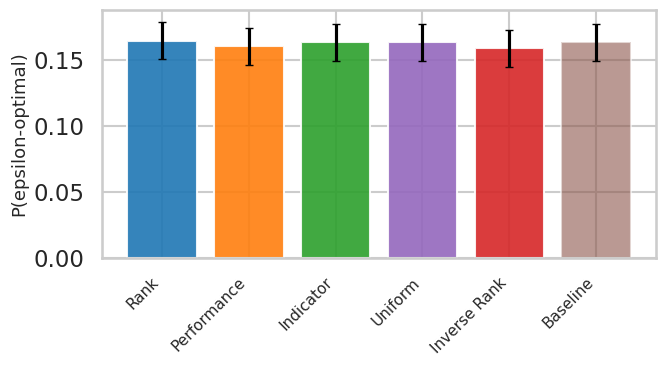

In [40]:
if sh_lcbench is not None:
    fig = epsilon_optimal_plot(sh_lcbench)
    os.makedirs("plots/successive_halving", exist_ok=True)
    fig.savefig("plots/successive_halving/epsilon_optimal_normalized.pdf", bbox_inches="tight")
    fig.savefig("plots/successive_halving/epsilon_optimal_normalized.png", bbox_inches="tight", dpi=300)
    plt.show()

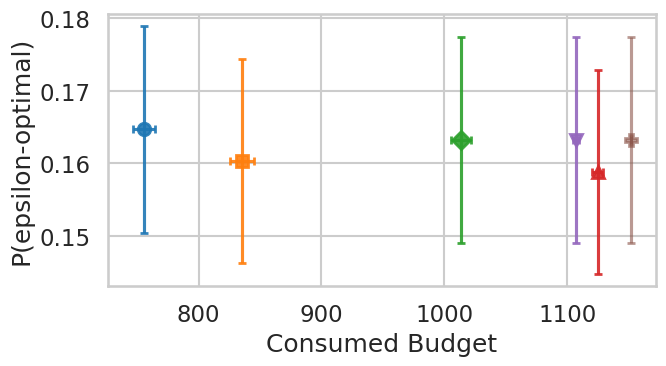

In [41]:
if sh_lcbench is not None:
    fig = budget_vs_epsilon_optimal_plot(sh_lcbench)
    os.makedirs("plots/successive_halving", exist_ok=True)
    fig.savefig("plots/successive_halving/budget_vs_epsilon_optimal_normalized.pdf", bbox_inches="tight")
    fig.savefig("plots/successive_halving/budget_vs_epsilon_optimal_normalized.png", bbox_inches="tight", dpi=300)
    plt.show()

## Variance Over Time

2026-05-06 23:23:39,452  | py-experimenter - INFO     | Found 14 keyfields
2026-05-06 23:23:39,453  | py-experimenter - INFO     | Found 6 resultfields
2026-05-06 23:23:39,453  | py-experimenter - INFO     | Found 2 logtables
2026-05-06 23:23:39,453  | py-experimenter - INFO     | Found logtable test_priorband__sh_iterations
2026-05-06 23:23:39,454  | py-experimenter - INFO     | Found logtable test_priorband__brackets
2026-05-06 23:23:39,454  | py-experimenter - WARNING  | No custom section defined in config
2026-05-06 23:23:39,454  | py-experimenter - WARNING  | No codecarbon section defined in config
2026-05-06 23:23:39,459  | py-experimenter - INFO     | Initialized and connected to database
2026-05-06 23:23:39,499  | py-experimenter - INFO     | Found 14 keyfields
2026-05-06 23:23:39,500  | py-experimenter - INFO     | Found 6 resultfields
2026-05-06 23:23:39,500  | py-experimenter - INFO     | Found 2 logtables
2026-05-06 23:23:39,500  | py-experimenter - INFO     | Found logtabl

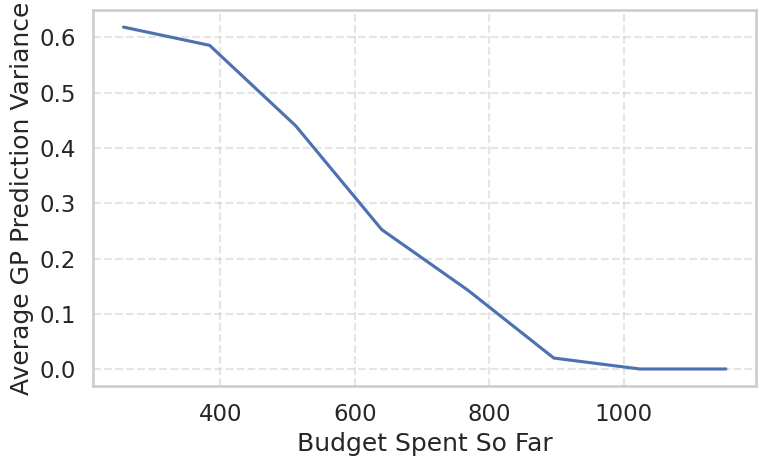

In [42]:
def get_logtable(table_name: str, update_data: bool) -> pd.DataFrame | None:
    cache_path = f"plain_data/{table_name}/logtable.csv"
    if update_data:
        try:
            experimenter = PyExperimenter(
                experiment_configuration_file_path="conf/experiment_config.yml",
                database_credential_file_path="conf/database_credentials.yml",
                table_name=table_name,
            )
            log_df = experimenter.get_logtable("sh_iterations")
            os.makedirs(os.path.dirname(cache_path), exist_ok=True)
            log_df.to_csv(cache_path, index=False)
            return log_df
        except Exception as e:
            print(f"Could not load logtable '{table_name}' from DB: {e}")
            if os.path.exists(cache_path):
                print(f"  Falling back to cached logtable for '{table_name}'.")
                return pd.read_csv(cache_path)
            return None
    else:
        if not os.path.exists(cache_path):
            print(f"No logtable cache found for '{table_name}', skipping.")
            return None
        return pd.read_csv(cache_path)


import ast

sh_log_dfs = []
for table_name in TABLE_NAMES_SH_UNNORMALIZED:
    main_df = get_data(table_name, update_data)
    log_df = get_logtable(table_name, update_data)
    if main_df is None or log_df is None:
        continue
    lcbench_ids = main_df[main_df["benchmark"] == "lcbench"]["ID"]
    log_df = log_df[log_df["experiment_id"].isin(lcbench_ids)].copy()
    log_df["use_early_stopping"] = main_df.set_index("ID").loc[
        log_df["experiment_id"].values, "use_early_stopping"
    ].values
    sh_log_dfs.append(log_df)

sh_log = pd.concat(sh_log_dfs, ignore_index=True)
sh_log = sh_log[sh_log["use_early_stopping"] == 0]
sh_log["variance"] = sh_log["arm_prediction_variances"].map(
    lambda s: float(np.mean(ast.literal_eval(s)))
)

avg_variance = (
    sh_log
    .groupby("budget_spent_so_far")["variance"]
    .agg(mean="mean", se=lambda x: x.std() / len(x) ** 0.5)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
avg_variance = avg_variance.sort_values("budget_spent_so_far")
ax.plot(avg_variance["budget_spent_so_far"], avg_variance["mean"])
ax.fill_between(
    avg_variance["budget_spent_so_far"],
    avg_variance["mean"] - avg_variance["se"],
    avg_variance["mean"] + avg_variance["se"],
    alpha=0.2,
)

ax.set_xlabel("Budget Spent So Far")
ax.set_ylabel("Average GP Prediction Variance")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
os.makedirs("plots/variance", exist_ok=True)
plt.savefig("plots/variance/variance_over_time_lcbench.pdf", bbox_inches="tight")
plt.savefig("plots/variance/variance_over_time_lcbench.png", bbox_inches="tight")
plt.show()

## Hyperband

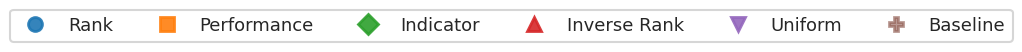

In [43]:
_prior_order = ["Rank", "Performance", "Indicator", "Inverse Rank", "Uniform", BASELINE_LABEL]
_pareto_handles = [
    plt.Line2D(
        [0], [0],
        marker=PRIOR_MARKER_MAP[p],
        color="w",
        markerfacecolor=PRIOR_COLOR_MAP[p],
        markeredgecolor=PRIOR_COLOR_MAP[p],
        markersize=LEGEND_MARKER_SIZE,
        markeredgewidth=MARKER_EDGE_WIDTH,
        alpha=ALPHA_BASELINE if p == BASELINE_LABEL else ALPHA_NORMAL,
        label=p,
    )
    for p in _prior_order
    if p in PRIOR_COLOR_MAP
]
_fig_lp, _ax_lp = plt.subplots(figsize=FIG_SIZE_LEGEND)
_ax_lp.axis("off")
_ax_lp.legend(
    handles=_pareto_handles,
    labels=[h.get_label() for h in _pareto_handles],
    loc="center",
    ncol=len(_pareto_handles),
    frameon=True,
    fontsize=LABEL_SIZE,
)
plt.tight_layout()
os.makedirs("plots/hyperband", exist_ok=True)
_fig_lp.savefig("plots/hyperband/legend_pareto.pdf", bbox_inches="tight")
_fig_lp.savefig("plots/hyperband/legend_pareto.png", bbox_inches="tight", dpi=300)
plt.show()

In [44]:
hb_lcbench = prepare_data(df_lcbench, "hyperband")
hb_lcbench

,ID,run_id,optimizer,num_arms,benchmark,kernel,use_predicted_y,use_early_stopping,seed,dataset_id,...,name,machine,T_max,consumed_budget,remaining_arms,num_epsilon_optimal_arms,regret,epsilon_optimal,end_date,error
0,1,__AUTO__,hyperband,256,lcbench,linear,0,1,0,0,...,PyExperimenter,cn1505,52,1065.0,1,7,0.000912,1,2026-05-04 18:16:40,None
1,2,__AUTO__,hyperband,256,lcbench,linear,0,1,1,0,...,PyExperimenter,cn0336,52,1091.0,1,14,0.002960,1,2026-05-04 18:16:21,None
2,3,__AUTO__,hyperband,256,lcbench,linear,0,1,2,0,...,PyExperimenter,cn1536,52,1091.0,1,10,0.000711,1,2026-05-04 18:16:25,None
3,4,__AUTO__,hyperband,256,lcbench,linear,0,1,3,0,...,PyExperimenter,cn0135,52,1091.0,1,10,0.002551,1,2026-05-04 18:16:10,None
4,5,__AUTO__,hyperband,256,lcbench,linear,0,1,4,0,...,PyExperimenter,cn0125,52,1091.0,1,8,0.001398,1,2026-05-04 18:16:11,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4075,676,__AUTO__,hyperband,256,lcbench,linear,0,0,15,33,...,PyExperimenter,cn1861,52,1091.0,1,3,0.058567,0,2026-05-04 18:12:36,None
4076,677,__AUTO__,hyperband,256,lcbench,linear,0,0,16,33,...,PyExperimenter,cn0111,52,1091.0,1,1,0.064760,0,2026-05-04 18:12:38,None
4077,678,__AUTO__,hyperband,256,lcbench,linear,0,0,17,33,...,PyExperimenter,cn1861,52,1091.0,1,1,0.086338,0,2026-05-04 18:14:53,None
4078,679,__AUTO__,hyperband,256,lcbench,linear,0,0,18,33,...,PyExperimenter,cn0728,52,1091.0,1,2,0.057293,0,2026-05-04 18:12:35,None


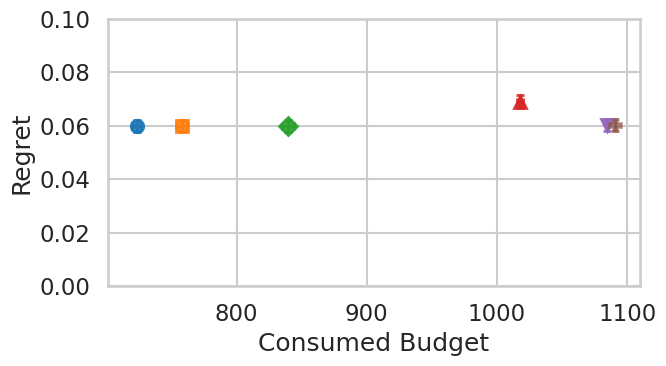

In [45]:
if hb_lcbench is not None:
    os.makedirs("plots/hyperband", exist_ok=True)
    fig = pareto_plot(hb_lcbench, ylim=YLIM_REGRET)
    fig.savefig("plots/hyperband/pareto.pdf", bbox_inches="tight")
    fig.savefig("plots/hyperband/pareto.png", bbox_inches="tight", dpi=300)
    plt.show()

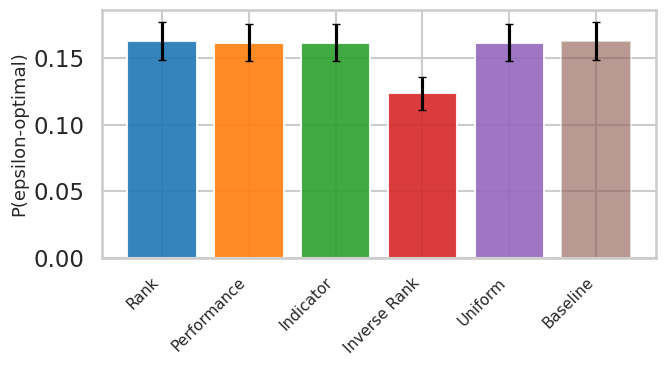

In [46]:
if hb_lcbench is not None:
    fig = epsilon_optimal_plot(hb_lcbench)
    os.makedirs("plots/hyperband", exist_ok=True)
    fig.savefig("plots/hyperband/epsilon_optimal.pdf", bbox_inches="tight")
    fig.savefig("plots/hyperband/epsilon_optimal.png", bbox_inches="tight", dpi=300)
    plt.show()

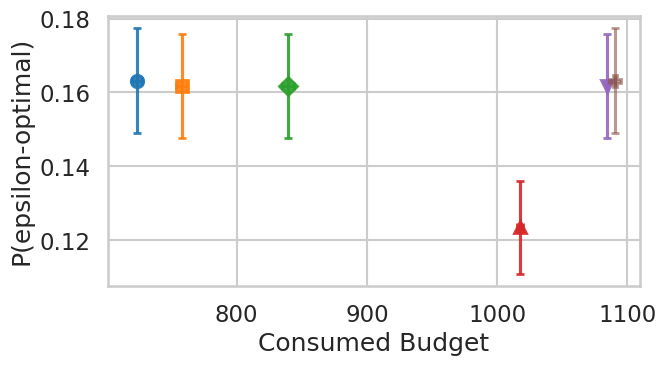

In [47]:
if hb_lcbench is not None:
    fig = budget_vs_epsilon_optimal_plot(hb_lcbench)
    os.makedirs("plots/hyperband", exist_ok=True)
    fig.savefig("plots/hyperband/budget_vs_epsilon_optimal.pdf", bbox_inches="tight")
    fig.savefig("plots/hyperband/budget_vs_epsilon_optimal.png", bbox_inches="tight", dpi=300)
    plt.show()

## PriorBand

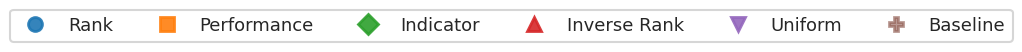

In [48]:
_prior_order = ["Rank", "Performance", "Indicator", "Inverse Rank", "Uniform", BASELINE_LABEL]
_pareto_handles = [
    plt.Line2D(
        [0], [0],
        marker=PRIOR_MARKER_MAP[p],
        color="w",
        markerfacecolor=PRIOR_COLOR_MAP[p],
        markeredgecolor=PRIOR_COLOR_MAP[p],
        markersize=LEGEND_MARKER_SIZE,
        markeredgewidth=MARKER_EDGE_WIDTH,
        alpha=ALPHA_BASELINE if p == BASELINE_LABEL else ALPHA_NORMAL,
        label=p,
    )
    for p in _prior_order
    if p in PRIOR_COLOR_MAP
]
_fig_lp, _ax_lp = plt.subplots(figsize=FIG_SIZE_LEGEND)
_ax_lp.axis("off")
_ax_lp.legend(
    handles=_pareto_handles,
    labels=[h.get_label() for h in _pareto_handles],
    loc="center",
    ncol=len(_pareto_handles),
    frameon=True,
    fontsize=LABEL_SIZE,
)
plt.tight_layout()
os.makedirs("plots/priorband", exist_ok=True)
_fig_lp.savefig("plots/priorband/legend_pareto.pdf", bbox_inches="tight")
_fig_lp.savefig("plots/priorband/legend_pareto.png", bbox_inches="tight", dpi=300)
plt.show()

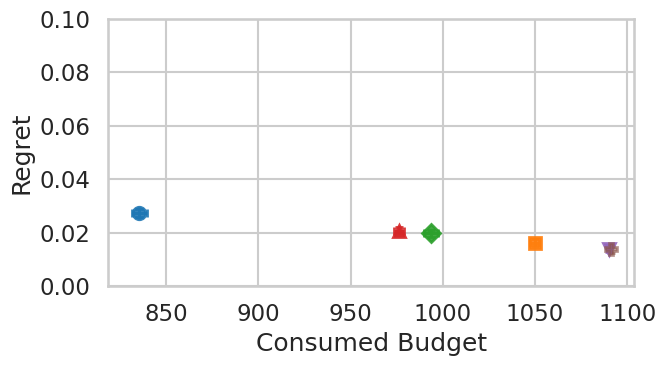

In [49]:
pb_lcbench = prepare_data(df_lcbench, "priorband")
if pb_lcbench is not None:
    os.makedirs("plots/priorband", exist_ok=True)
    fig = pareto_plot(pb_lcbench, ylim=YLIM_REGRET)
    fig.savefig("plots/priorband/pareto.pdf", bbox_inches="tight")
    fig.savefig("plots/priorband/pareto.png", bbox_inches="tight", dpi=300)
    plt.show()

### Joined Pareto Front

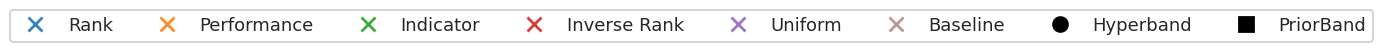

In [50]:
_prior_order = ["Rank", "Performance", "Indicator", "Inverse Rank", "Uniform", BASELINE_LABEL]
_color_handles = [
    plt.Line2D(
        [0], [0],
        marker="x",
        color="w",
        markerfacecolor=PRIOR_COLOR_MAP.get(p, "gray"),
        markeredgecolor=PRIOR_COLOR_MAP.get(p, "gray"),
        markersize=LEGEND_MARKER_SIZE,
        markeredgewidth=MARKER_EDGE_WIDTH,
        alpha=ALPHA_BASELINE if p == BASELINE_LABEL else ALPHA_NORMAL,
        label=p,
    )
    for p in _prior_order
    if p in PRIOR_COLOR_MAP
]
_marker_handles = [
    plt.Line2D(
        [0], [0],
        marker=m,
        color="w",
        markerfacecolor="black",
        markeredgecolor="black",
        markersize=LEGEND_MARKER_SIZE,
        markeredgewidth=MARKER_EDGE_WIDTH,
        label=label,
    )
    for label, m in OPTIMIZER_MARKER.items()
]
_all_handles = _color_handles + _marker_handles
_fig_lj, _ax_lj = plt.subplots(figsize=FIG_SIZE_LEGEND)
_ax_lj.axis("off")
_ax_lj.legend(
    handles=_all_handles,
    labels=[h.get_label() for h in _all_handles],
    loc="center",
    ncol=len(_all_handles),
    frameon=True,
    fontsize=LABEL_SIZE,
)
plt.tight_layout()
os.makedirs("plots/priorband", exist_ok=True)
_fig_lj.savefig("plots/priorband/legend_joined.pdf", bbox_inches="tight")
_fig_lj.savefig("plots/priorband/legend_joined.png", bbox_inches="tight", dpi=300)
plt.show()

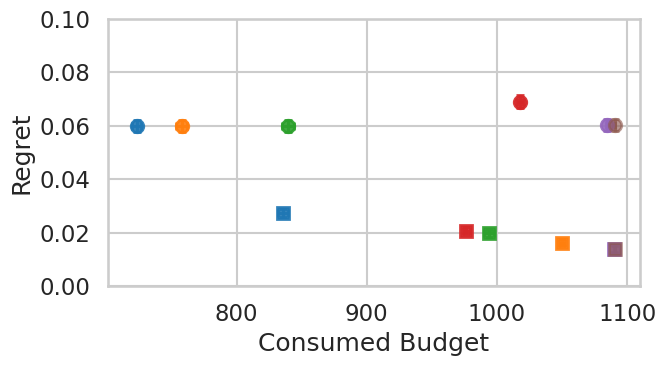

In [51]:
if hb_lcbench is not None and pb_lcbench is not None:
    os.makedirs("plots/priorband", exist_ok=True)
    fig = joined_pareto_plot(hb_lcbench, pb_lcbench, ylim=YLIM_REGRET)
    fig.savefig("plots/priorband/joined_pareto.pdf", bbox_inches="tight")
    fig.savefig("plots/priorband/joined_pareto.png", bbox_inches="tight", dpi=300)
    plt.show()